# Latent feature space investigation

In [34]:
%load_ext autoreload
%autoreload 2

import os
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

# Pipeline visualization module (Crameri scientific colour maps)
from visualization import (
    # embedding I/O
    collect_embeddings,
    read_clinical_data,
    build_embedding_matrix,
    prepare_labels,
    # latent-space plots
    plot_umap,
    plot_tsne,
    plot_pca,
    plot_umap_interactive,
    plot_cosine_distance_clustermap,
    plot_silhouette_per_group,
    plot_dendrogram,
    plot_kmeans_confusion,
    compute_silhouette,
    compute_umap,
    # distribution plots
    plot_countplot,
    plot_stacked_bar,
    plot_mosaic,
    # core helpers
    setup_style,
)

setup_style()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# --------------------------------------------------------------
# Paths  (edit these to point at your experiment)
# --------------------------------------------------------------
ROOT_DIR     = "/mnt/bulk-saturn/maralampert/genhist/experiments/20260126_trying_to_get_the_whole_picture_with_existing_diffusion_model_checkpoint_but_without_properly_handling_genomics/full_train_512/mopadi_features"
CLINICAL_CSV = os.path.join(ROOT_DIR, "clinical_table.csv")
MAP_CSV      = os.path.join(ROOT_DIR, "encoded_id_to_orig_map.csv")
PLOT_DIR     = Path("/mnt/bulk-saturn/maralampert/genhist/Master-Thesis-Repository/plots")

# --------------------------------------------------------------
# Load & merge
# --------------------------------------------------------------
df_emb  = collect_embeddings(ROOT_DIR)
df_clin = read_clinical_data(CLINICAL_CSV, MAP_CSV)
df_all  = df_emb.merge(df_clin, on=["encoded_id", "split"], how="inner")
print(f"🗂️  Final table shape: {df_all.shape}")
df_all.head()

In [36]:
# --------------------------------------------------------------
# Sanity checks & embedding matrix
# --------------------------------------------------------------
print("Unique splits :", df_all["split"].unique())
print("Subtype distribution:\n", df_all["Majority_Subtype_mRNA"].value_counts())
assert not df_all["embedding"].isna().any(), "Missing embeddings!"

X         = build_embedding_matrix(df_all)
y_subtype = prepare_labels(df_all, "Majority_Subtype_mRNA")
y_split   = prepare_labels(df_all, "split")

print(f"X.shape = {X.shape}  (expect n_samples × 512)")

Unique splits : ['train' 'test']
Subtype distribution:
 Majority_Subtype_mRNA
LumA      512
LumB      195
Basal     174
Her2       74
Normal     38
Name: count, dtype: int64
X.shape = (993, 512)  (expect n_samples × 512)


/mnt/bulk-saturn/maralampert/genhist/Master-Thesis-Repository/src/visualization/distributions.py:82: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




[OK] Saved figure → /mnt/bulk-saturn/maralampert/genhist/Master-Thesis-Repository/plots/distribution_subtypes.png


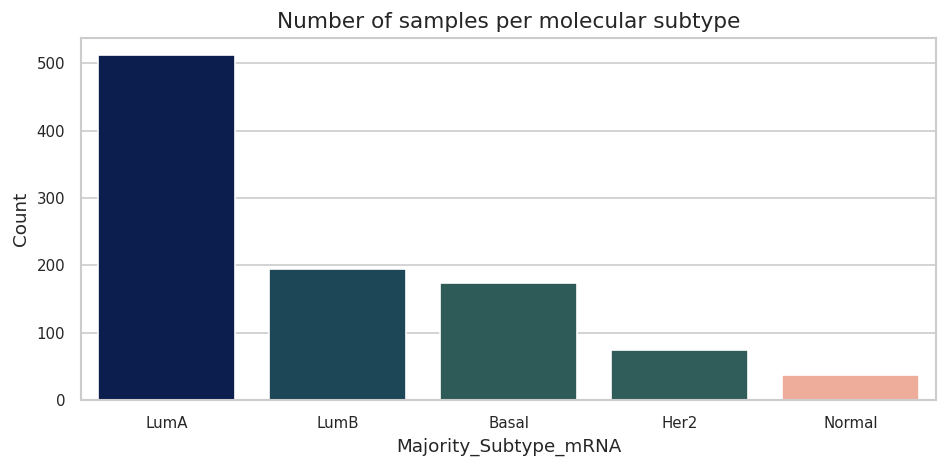

[OK] Saved figure → /mnt/bulk-saturn/maralampert/genhist/Master-Thesis-Repository/plots/distribution_train_test_among_subgroups.png


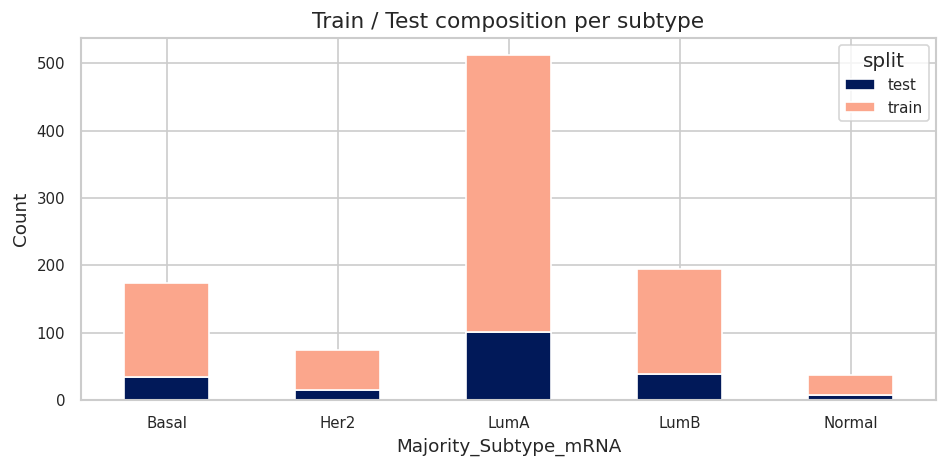

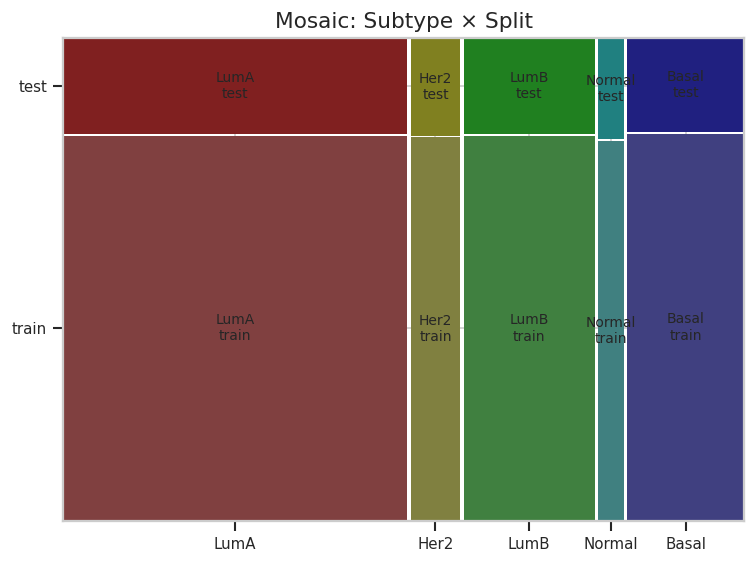

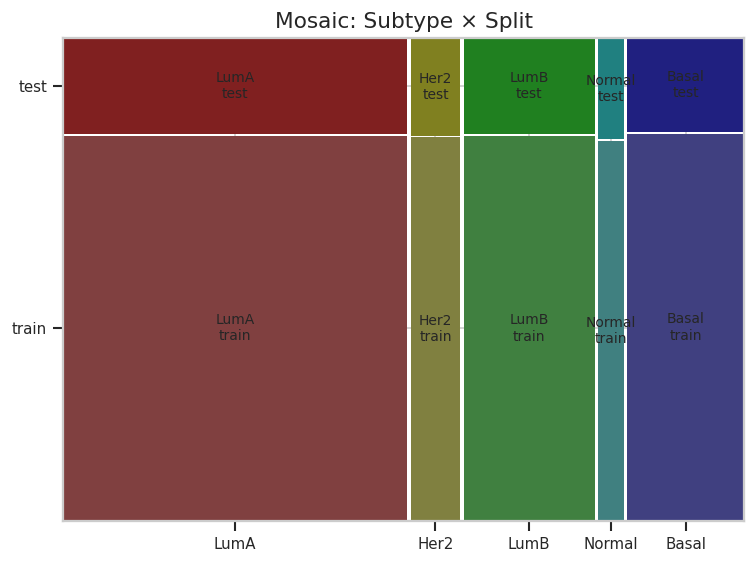

In [37]:
# --------------------------------------------------------------
# Distribution plots
# --------------------------------------------------------------
plot_countplot(df_all, x="Majority_Subtype_mRNA",
               title="Number of samples per molecular subtype",
               save_path=PLOT_DIR / "distribution_subtypes.png")

plot_stacked_bar(df_all,
                 group_col="Majority_Subtype_mRNA",
                 stack_col="split",
                 title="Train / Test composition per subtype",
                 save_path=PLOT_DIR / "distribution_train_test_among_subgroups.png")

plot_mosaic(df_all,
            columns=["Majority_Subtype_mRNA", "split"],
            title="Mosaic: Subtype × Split")

## UMAP

/mnt/bulk-saturn/maralampert/genhist/Master-Thesis-Repository/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



[OK] Saved figure → /mnt/bulk-saturn/maralampert/genhist/Master-Thesis-Repository/plots/UMAP_train_test_PAM50.png


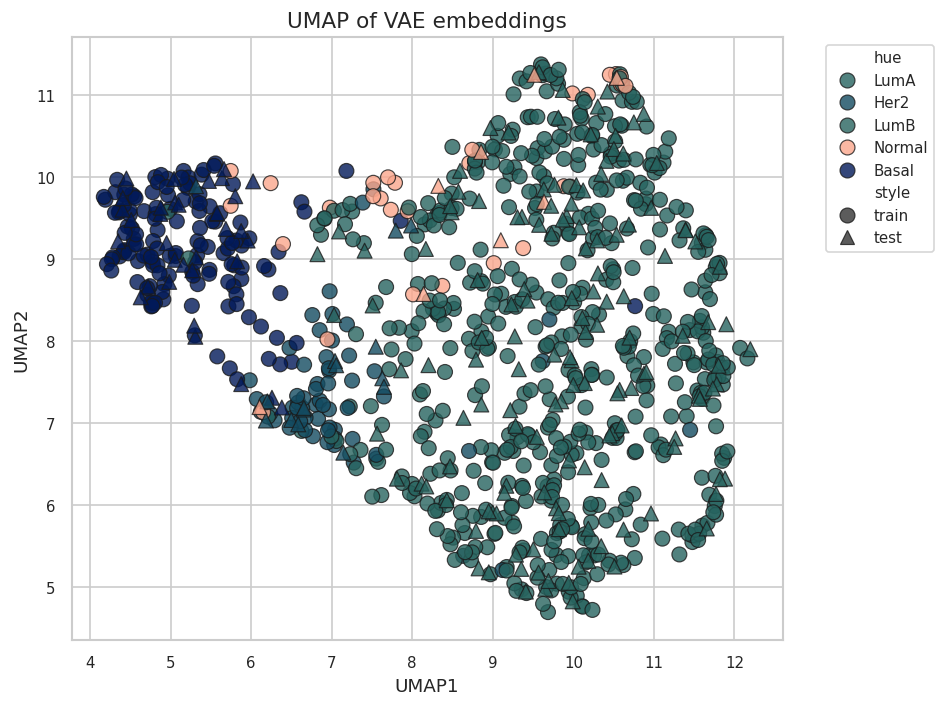

In [38]:
# --------------------------------------------------------------
# UMAP
# --------------------------------------------------------------
markers = {"train": "o", "test": "^"}

X_umap, _ = plot_umap(
    X, y_subtype,
    style_labels=y_split,
    markers=markers,
    save_path=PLOT_DIR / "UMAP_train_test_PAM50.png",
)

# Store coordinates for downstream cells
df_all["UMAP1"] = X_umap[:, 0]
df_all["UMAP2"] = X_umap[:, 1]

## tSNE

/mnt/bulk-saturn/maralampert/genhist/Master-Thesis-Repository/.venv/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



[OK] Saved figure → /mnt/bulk-saturn/maralampert/genhist/Master-Thesis-Repository/plots/tSNE_train_test_PAM50.png


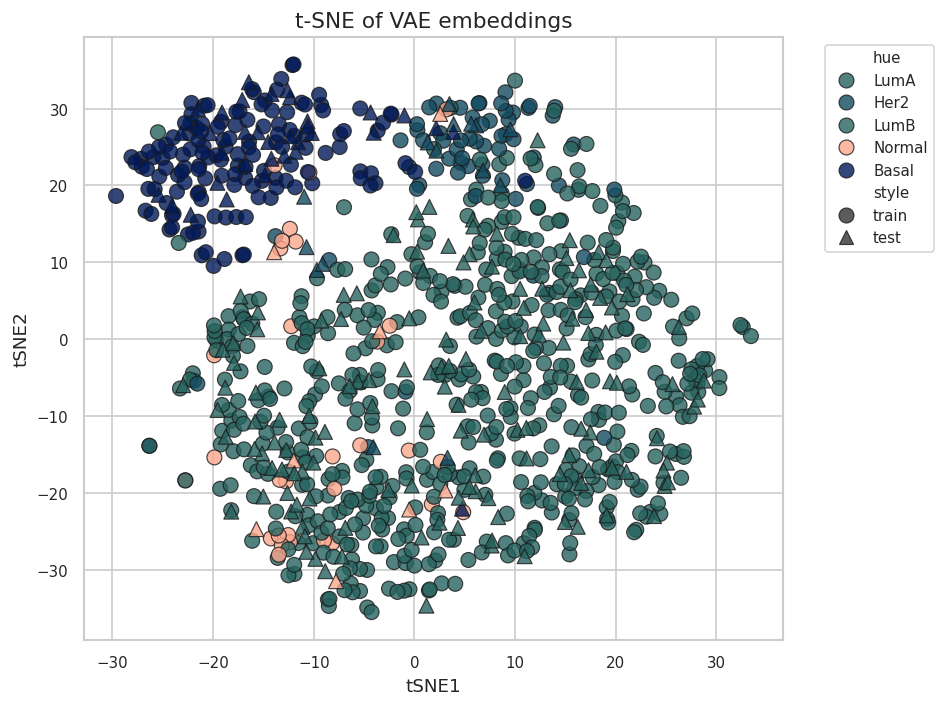

In [39]:
# --------------------------------------------------------------
# t-SNE
# --------------------------------------------------------------
X_tsne, _ = plot_tsne(
    X, y_subtype,
    style_labels=y_split,
    markers=markers,
    save_path=PLOT_DIR / "tSNE_train_test_PAM50.png",
)

df_all["tSNE1"] = X_tsne[:, 0]
df_all["tSNE2"] = X_tsne[:, 1]

## PCA

[OK] Saved figure → /mnt/bulk-saturn/maralampert/genhist/Master-Thesis-Repository/plots/PCA_train_test_PAM50.png


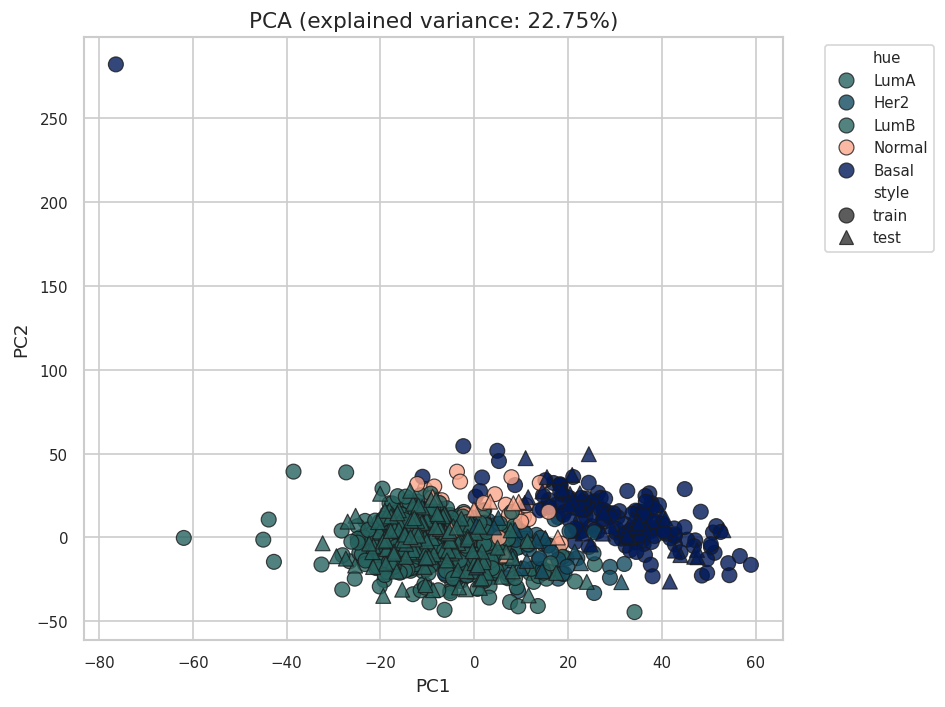

In [41]:
X_pca, pca_obj, _ = plot_pca(
    X, y_subtype,
    style_labels=y_split,
    markers=markers,
    save_path=PLOT_DIR / "PCA_train_test_PAM50.png",
)

df_all["PC1"] = X_pca[:, 0]
df_all["PC2"] = X_pca[:, 1]

## Pairwise cosine distance heatmap (clustered)

/mnt/bulk-saturn/maralampert/genhist/Master-Thesis-Repository/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning:

Clustering large matrix with scipy. Installing `fastcluster` may give better performance.

/mnt/bulk-saturn/maralampert/genhist/Master-Thesis-Repository/.venv/lib/python3.12/site-packages/seaborn/matrix.py:530: ClusterWarning:

The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix

/mnt/bulk-saturn/maralampert/genhist/Master-Thesis-Repository/.venv/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning:

Clustering large matrix with scipy. Installing `fastcluster` may give better performance.

/mnt/bulk-saturn/maralampert/genhist/Master-Thesis-Repository/.venv/lib/python3.12/site-packages/seaborn/matrix.py:530: ClusterWarning:

The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix



[OK] Saved figure → /mnt/bulk-saturn/maralampert/genhist/Master-Thesis-Repository/plots/cosine_distance_matrix_clustermap.png


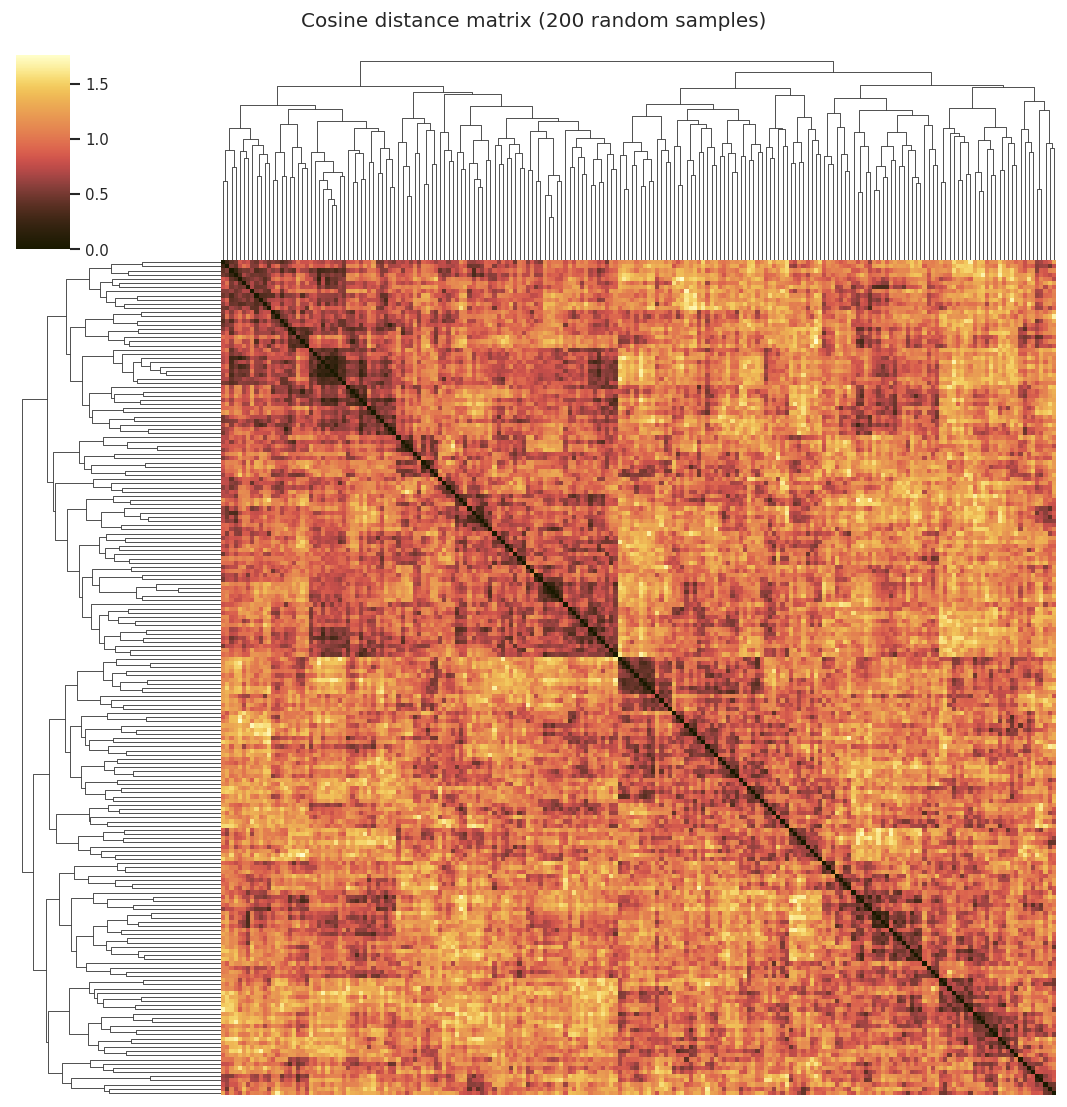

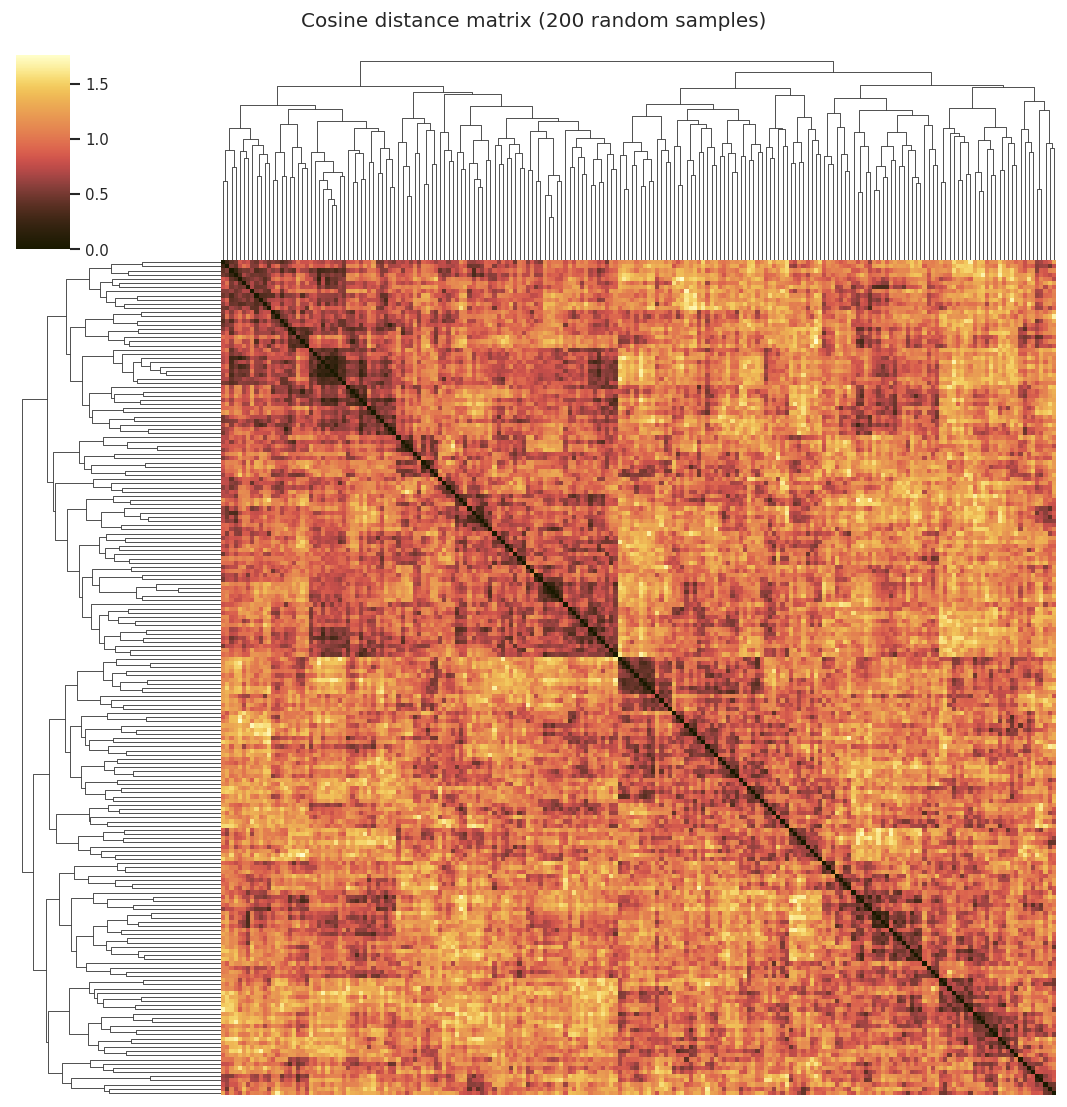

In [42]:
plot_cosine_distance_clustermap(
    X, n_samples=200,
    save_path=PLOT_DIR / "cosine_distance_matrix_clustermap.png",
)

## Silhouette analysis

Silhouette (raw 512-D, cosine):    0.038
Silhouette (UMAP 2-D, euclidean):  0.094


/mnt/bulk-saturn/maralampert/genhist/Master-Thesis-Repository/src/visualization/latent_space.py:552: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




[OK] Saved figure → /mnt/bulk-saturn/maralampert/genhist/Master-Thesis-Repository/plots/silhouette_per_subtype_umap.png


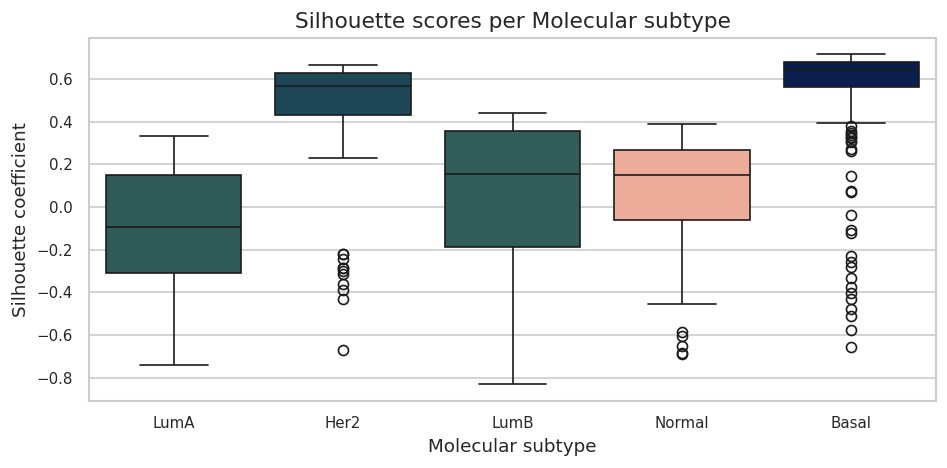

In [43]:
sil_raw  = compute_silhouette(X, y_subtype, metric="cosine")
sil_umap = compute_silhouette(X_umap, y_subtype, metric="euclidean")
print(f"Silhouette (raw 512-D, cosine):    {sil_raw:.3f}")
print(f"Silhouette (UMAP 2-D, euclidean):  {sil_umap:.3f}")

plot_silhouette_per_group(
    X_umap, y_subtype,
    group_col_name="Molecular subtype",
    metric="euclidean",
    save_path=PLOT_DIR / "silhouette_per_subtype_umap.png",
)

df_all["silhouette"] = __import__("sklearn.metrics", fromlist=["silhouette_samples"]).silhouette_samples(X_umap, y_subtype)

## Hierarchical clustering dendrogram (Ward linkage) on a subset

[OK] Saved figure → /mnt/bulk-saturn/maralampert/genhist/Master-Thesis-Repository/plots/ward_dendrogram_cosine_150_samples.png


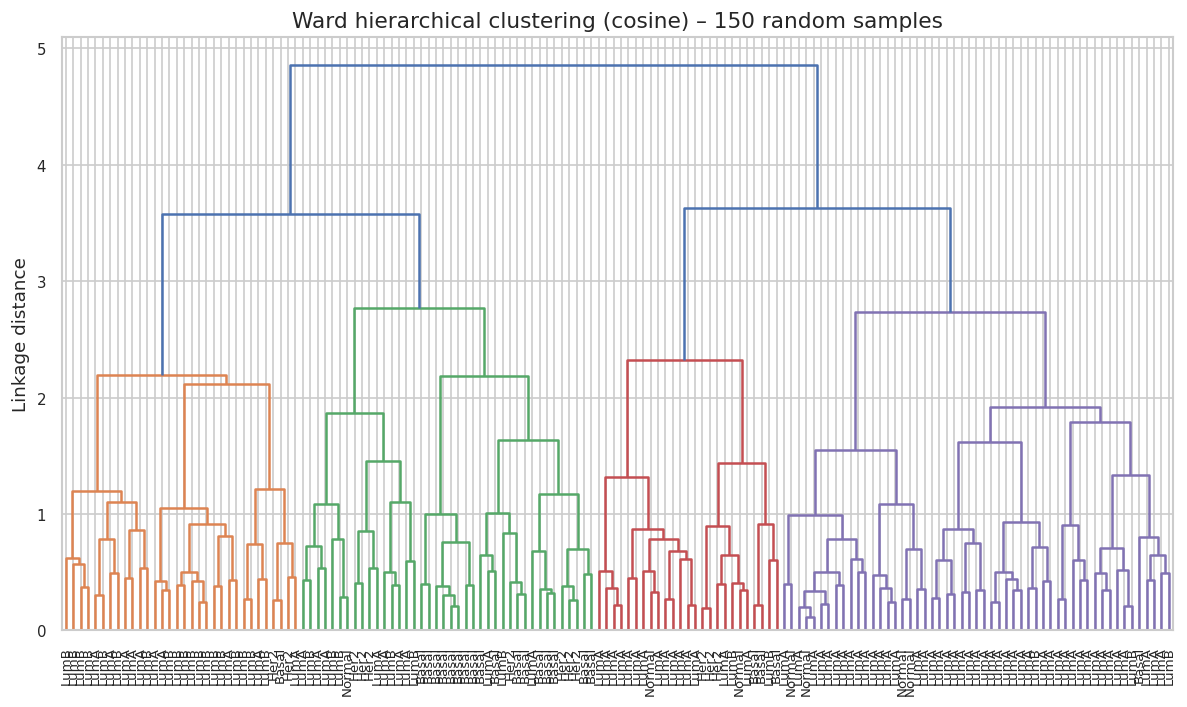

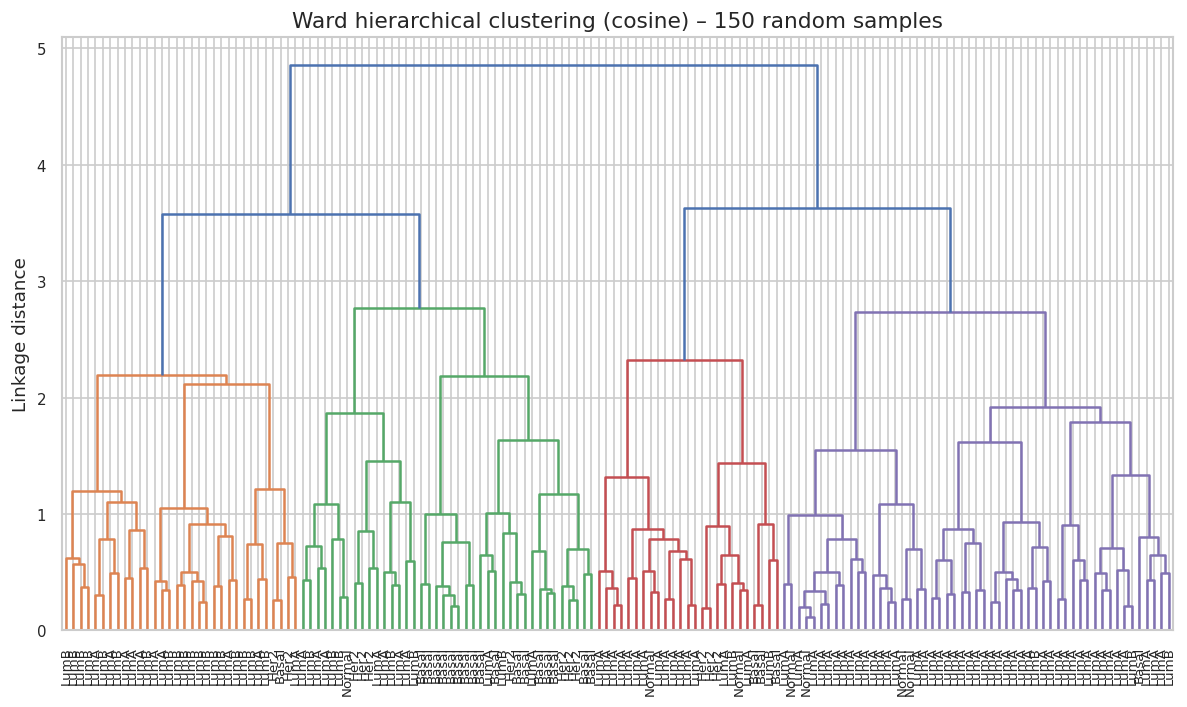

In [44]:
plot_dendrogram(
    X, y_subtype,
    n_samples=150,
    metric="cosine",
    method="ward",
    save_path=PLOT_DIR / "ward_dendrogram_cosine_150_samples.png",
)

## Interactive Plotly UMAP

In [45]:
plot_umap_interactive(
    df_all,
    color_col="Majority_Subtype_mRNA",
    symbol_col="split",
    hover_cols=["PATIENT", "encoded_id"],
    save_html=PLOT_DIR / "interactive_umap.html",
)

[OK] Saved interactive plot → /mnt/bulk-saturn/maralampert/genhist/Master-Thesis-Repository/plots/interactive_umap.html
